# bankpanel quickstart

python examples/quickstart.py --call-root <panel_root> --y9c-root <y9c_root>

or set BANKPANEL_CALL_ROOT / BANKPANEL_Y9C_ROOT. Each root is the ``--out`` of a
``bankpanel build`` (plus ``bankpanel expectations build``, which step 4 needs).

What it shows
  1. what is in a panel: the build manifest and the dictionary
  2. reading columns, with the form type every row carries
  3. year-to-date income items: ``ytd_`` as filed and ``q_`` as a quarterly flow
  4. NaN is not one thing: ``expected_mask`` separates "not collected" from "left blank"
  5. the holding-company panel uses the same names, so the two line up column for column
  6. one figure: aggregate loans-to-assets and net interest margin, banks vs holding companies

Values are thousands of US dollars. Nothing here is cleaned, winsorized or merger-adjusted;
see docs/CAVEATS.md before using the data for research.

In [1]:
import os
from pathlib import Path
from types import SimpleNamespace

import pandas as pd

import bankpanel as bp

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 20)

# Point these at the --out of `bankpanel build` (and `bankpanel expectations build`).
args = SimpleNamespace(
    call_root=os.environ.get("BANKPANEL_CALL_ROOT", "panel_root"),
    y9c_root=os.environ.get("BANKPANEL_Y9C_ROOT", "y9c_root"),
    out=Path("output"),
)
call, y9c = Path(args.call_root), Path(args.y9c_root)
print("bankpanel", bp.__version__, "| Call panel:", call, "| Y-9C panel:", y9c)

COLS = ["assets", "ll_tot", "ll_res", "equity", "dom_deposit_nib", "dom_deposit_ib", "foreign_dep",
        "ytd_int_inc", "ytd_int_exp", "q_int_inc", "q_int_exp"]


def section(title):
    print(title)


bankpanel 0.7.0 | Call panel: C:\Users\Matthew\.claude\jobs\1cc4f885\tmp\panel_v26 | Y-9C panel: C:\Users\Matthew\OneDrive\GitHub\bec_migration\data\y9c_panel


## 1. what is in a panel

In [2]:
manifest = bp.info(root=call)
print(f"built {manifest['built_at']} with bankpanel {manifest['bankpanel_version']} | profile {manifest['profile']} | "
      f"{int(manifest['n_rows']):,} rows x {manifest['n_columns']} columns | {manifest['date_min']} .. {manifest['date_max']}")
d = bp.dictionary(root=call)
print(f"{len(d):,} columns: {d.variable_type.value_counts().to_dict()}")
print("schedules:", ", ".join(sorted(d.schedule.dropna().unique())))
print("\nsearch_variables('nonaccrual') ->")
print(bp.search_variables("nonaccrual", root=call)[["variable_name", "schedule", "mdrm_code", "description"]].head(6).to_string(index=False))

built 2026-09-24T09:36:18 with bankpanel 0.1.0.dev0 | profile ffiec_call | 1,415,045 rows x 1178 columns | 1985Q1 .. 2025Q3
1,294 columns: {'base': 954, 'derived': 210, 'flow': 130}
schedules: CROSS, RC, RC-B, RC-C, RC-D, RC-E, RC-F, RC-G, RC-K, RC-L, RC-M, RC-N, RC-O, RC-P, RC-Q, RC-R, RC-R-I, RC-T, RI, RI-A, RI-B, RI-C

search_variables('nonaccrual') ->
   variable_name schedule mdrm_code                                                                        description
dsec_oth_ass_non     RC-N  RCFD3507                                      DEBT SECURITIES AND OTHER ASSETS - NONACCRUAL
na_famres_closed       RC  RCON5403         LOANS SECURED BY 1-4 FAMILY RESIDENTIAL PROPERTIES: ALL OTHER - NONACCRUAL
     na_tot_1403     RC-N  RCFD1403                              TOTAL LOANS AND LEASE FINANCE RECEIVABLES: NONACCRUAL
      na_re_f176     RC-N  RCONF176                              1-4 FAMILY RESIDENTIAL CONSTRUCTION LOANS; NONACCRUAL
      na_re_f177     RC-N  RCONF177 OTHER CONST

## 2. reading columns

In [3]:
df = bp.read_panel(COLS, start="1997Q1", root=call)
df["date"] = df["REPORTING_PERIOD"]
print(f"{len(df):,} bank-quarters x {df.shape[1]} columns, {df.date.min().date()} .. {df.date.max().date()}")
print(df.head(4).to_string(index=False))
print("\nEvery row carries form_type (31 = with foreign offices, 41 = domestic, 51 = the short form since 2017):")
ft = df.groupby([df.date.dt.year, "form_type"]).size().unstack(fill_value=0)
print(ft.loc[[1997, 2005, 2011, 2017, 2020, 2024]].to_string())

805,954 bank-quarters x 15 columns, 1997-03-31 .. 2025-09-30
 RSSD_ID REPORTING_PERIOD  form_type  assets  ll_tot  ll_res  equity  dom_deposit_nib  dom_deposit_ib  foreign_dep  ytd_int_inc  ytd_int_exp  q_int_inc  q_int_exp       date
      37       1997-03-31       41.0 58891.0 34410.0   652.0  8782.0           6141.0         43606.0          NaN       1178.0        539.0     1178.0      539.0 1997-03-31
      37       1997-06-30       41.0 57317.0 35147.0   731.0  8899.0           5253.0         42844.0          NaN       2405.0       1089.0     1227.0      550.0 1997-06-30
      37       1997-09-30       41.0 57993.0 37452.0   791.0  9115.0           4890.0         43543.0          NaN       3654.0       1659.0     1249.0      570.0 1997-09-30
      37       1997-12-31       41.0 60834.0 36851.0   775.0  9248.0           5859.0         45424.0          NaN       4928.0       2238.0     1274.0      579.0 1997-12-31

Every row carries form_type (31 = with foreign offices, 41 = domesti

## 3. ytd_ and q_

In [4]:
bank = df[df.RSSD_ID == df.loc[df.date == df.date.max(), "RSSD_ID"].iloc[0]].sort_values("date")
bank = bank[bank.date.dt.year == bank.date.dt.year.max() - 1]
print(f"one bank (RSSD {int(bank.RSSD_ID.iloc[0])}), one calendar year -- ytd_int_inc accumulates, q_int_inc is the difference:")
print(bank[["date", "form_type", "ytd_int_inc", "q_int_inc"]].to_string(index=False))
q = df.date.dt.quarter
missing_q = df.q_int_inc.isna().groupby(q).mean()
print("\nshare of bank-quarters with NO q_int_inc, by calendar quarter (Q1 = the YTD value itself):")
print((missing_q * 100).round(2).rename("% missing").to_string())
print("A q_ is NaN wherever no clean one-quarter difference exists (a bank missing the prior quarter,\n"
      "an annual filer, a first filing mid-year). It is never fabricated; the ytd_ column keeps what was filed.")

one bank (RSSD 37), one calendar year -- ytd_int_inc accumulates, q_int_inc is the difference:
      date  form_type  ytd_int_inc  q_int_inc
2024-03-31       51.0        816.0      816.0
2024-06-30       51.0       1671.0      855.0
2024-09-30       51.0       2531.0      860.0
2024-12-31       51.0       3413.0      882.0

share of bank-quarters with NO q_int_inc, by calendar quarter (Q1 = the YTD value itself):
date
1    0.00
2    0.33
3    0.29
4    0.33
A q_ is NaN wherever no clean one-quarter difference exists (a bank missing the prior quarter,
an annual filer, a first filing mid-year). It is never fabricated; the ytd_ column keeps what was filed.


## 4. expected_mask

In [5]:
col = "ln_famres_first_adjrate"          # RC-C memoranda: adjustable-rate closed-end first liens
c = bp.read_panel([col], start="2018Q1", root=call)
exp = bp.expected_mask(c, col, root=call)
tab = pd.DataFrame({"reported": c[col].notna(), "expected": exp})
summary = tab.groupby([c.form_type, c.REPORTING_PERIOD.dt.quarter]).agg(
    n=("reported", "size"), reported=("reported", "mean"), expected=("expected", "mean"))
print(f"{col} (Schedule RC-C memoranda) since 2018, by form and calendar quarter:")
print((summary.assign(reported=lambda s: (100 * s.reported).round(1), expected=lambda s: (100 * s.expected).round(1))
       .rename(columns={"reported": "% reported", "expected": "% expected"})).to_string())
print("\nThe 041 collects this item every quarter; the 051 short form collects it only in Q2 and Q4.\n"
      "So a NaN in a 051 filer's Q1 or Q3 is 'not collected' (expected = False), while a NaN where\n"
      "expected = True is a bank that left the line blank. Averaging the raw column over 2018+\n"
      "without this distinction silently turns Q1/Q3 into a 041-only sample.")
blank = tab[tab.expected & ~tab.reported]
print(f"cells expected but blank: {len(blank):,} of {int(tab.expected.sum()):,} expected ({100 * len(blank) / max(1, tab.expected.sum()):.2f}%)")

ln_famres_first_adjrate (Schedule RC-C memoranda) since 2018, by form and calendar quarter:
                                n  % reported  % expected
form_type REPORTING_PERIOD                               
31.0      1                   644       100.0       100.0
          2                   643       100.0       100.0
          3                   645       100.0       100.0
          4                   563       100.0       100.0
41.0      1                 10447       100.0       100.0
          2                 10337       100.0       100.0
          3                 10099       100.0       100.0
          4                  8967       100.0       100.0
51.0      1                 28879         0.5         0.0
          2                 28666       100.0       100.0
          3                 28607         0.4         0.0
          4                 25030       100.0       100.0

The 041 collects this item every quarter; the 051 short form collects it only in Q2 and Q4.
So 

## 5. the FR Y-9C panel, same names

In [6]:
hh = bp.read_panel(COLS, start="1997Q1", root=y9c)
hh["date"] = hh["REPORTING_PERIOD"]
print(f"{len(hh):,} holding-company-quarters | form_type here is the $5bn size tier (1 = under $5bn, 2 = $5bn and over)")
print(hh.head(3).to_string(index=False))
both = pd.concat([df.assign(panel="banks (Call)"), hh.assign(panel="holding companies (Y-9C)")])
agg = both.groupby(["panel", "date"]).agg(assets=("assets", "sum"), loans=("ll_tot", "sum"),
                                          ii=("q_int_inc", "sum"), ie=("q_int_exp", "sum"), n=("RSSD_ID", "size"))
agg["loans_to_assets"] = agg.loans / agg.assets
agg["nim_annualized_pct"] = 400 * (agg.ii - agg.ie) / agg.assets
latest = agg.reset_index().sort_values("date").groupby("panel").tail(1)
print("\nlatest quarter, aggregated:")
print(latest[["panel", "date", "n", "assets", "loans_to_assets", "nim_annualized_pct"]].to_string(index=False))

126,003 holding-company-quarters | form_type here is the $5bn size tier (1 = under $5bn, 2 = $5bn and over)
 RSSD_ID REPORTING_PERIOD  form_type   assets   ll_tot  ll_res  equity  dom_deposit_nib  dom_deposit_ib  foreign_dep  ytd_int_inc  ytd_int_exp  q_int_inc  q_int_exp       date
  571751       1997-03-31          1 379882.0 204610.0  2401.0 65090.0          62183.0        235099.0          0.0       7061.0       2614.0     7061.0     2614.0 1997-03-31
  571751       1997-06-30          1 381593.0 211936.0  2400.0 66017.0          50145.0        247400.0          0.0      13595.0       5685.0     6534.0     3071.0 1997-06-30
  571751       1997-09-30          1 389779.0 219075.0  2362.0 68033.0          51232.0        251847.0          0.0      21032.0       8537.0     7437.0     2852.0 1997-09-30

latest quarter, aggregated:
                   panel       date    n       assets  loans_to_assets  nim_annualized_pct
            banks (Call) 2025-09-30 4435 2.513297e+10         0.5255

## 6. figure

wrote output\quickstart.png


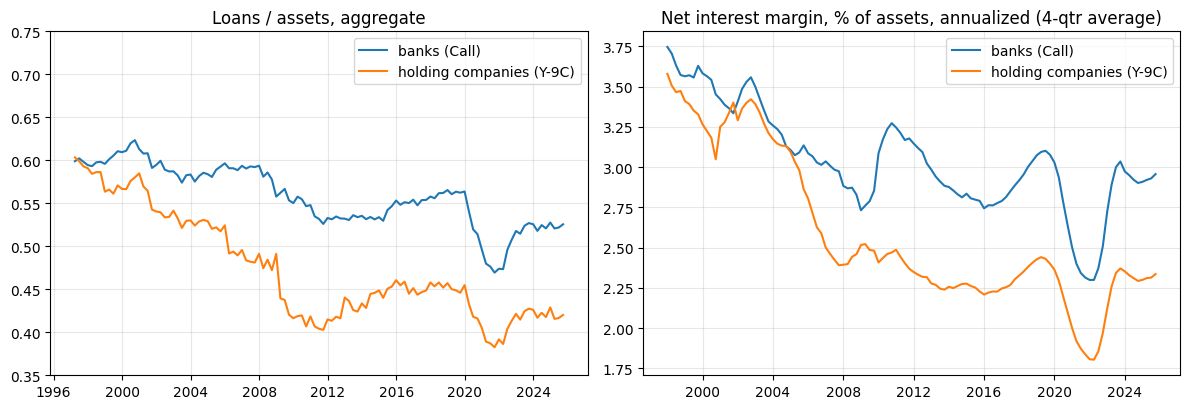

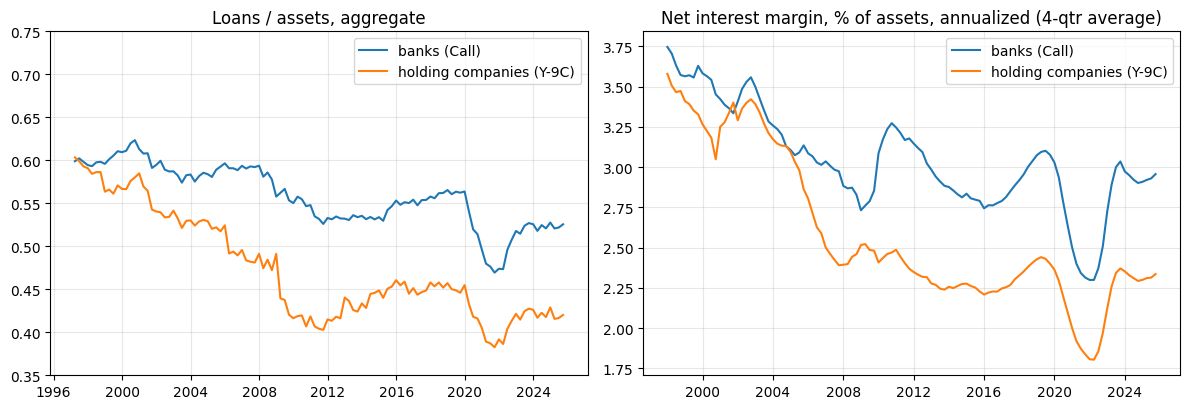

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for panel, g in agg.groupby(level="panel"):
    g = g.droplevel("panel")
    axes[0].plot(g.index, g.loans_to_assets, label=panel)
    axes[1].plot(g.index, g.nim_annualized_pct.rolling(4).mean(), label=panel)
axes[0].set_title("Loans / assets, aggregate")
axes[0].set_ylim(0.35, 0.75)
axes[1].set_title("Net interest margin, % of assets, annualized (4-qtr average)")
for ax in axes:
    ax.grid(alpha=.3)
    ax.legend()
out = Path(args.out)
out.mkdir(parents=True, exist_ok=True)
fig.tight_layout()
fig.savefig(out / "quickstart.png", dpi=120)
print("wrote", out / "quickstart.png")
fig